# Delta Lake Incremental Data Processing & SCD Assignment

This notebook demonstrates incremental data processing using Delta Lake's `MERGE` operation.
We cover base data ingestion, cleaning, SCD Type 1 (overwrite updates), SCD Type 2 (historical version tracking), and integrity validations.


In [1]:
import os
import shutil
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable, write_deltalake
import duckdb

# Load raw datasets
master_df = pd.read_csv('../data/customer_master.csv', dtype={'Postal_Code': str, 'End_Date': str})
incremental_df = pd.read_csv('../data/customer_incremental.csv', dtype={'Postal_Code': str, 'End_Date': str})

print(f"Master Dataset: {master_df.shape[0]} rows, {master_df.shape[1]} columns")
print(f"Incremental Dataset: {incremental_df.shape[0]} rows, {incremental_df.shape[1]} columns")

master_df.head(5)


Master Dataset: 793 rows, 16 columns
Incremental Dataset: 50 rows, 16 columns


,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Total_Sales,Total_Orders,Credit_Score,Is_Active,Effective_Date,End_Date,Record_Version,Updated_At
0,AA-10315,Alex Avila,Consumer,United States,Minneapolis,Minnesota,55407,Central,5563.56,11,702,True,2026-01-01,9999-12-31,1,2026-01-01T00:00:00
1,AA-10375,Allen Armold,Consumer,United States,Mesa,Arizona,85204,West,1056.39,15,779,True,2026-01-01,9999-12-31,1,2026-01-01T00:00:00
2,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,South,1790.51,12,692,True,2026-01-01,9999-12-31,1,2026-01-01T00:00:00
3,AA-10645,Anna Andreadi,Consumer,United States,Chester,Pennsylvania,19013,East,5086.93,18,614,True,2026-01-01,9999-12-31,1,2026-01-01T00:00:00
4,AB-10015,Aaron Bergman,Consumer,United States,Seattle,Washington,98103,West,886.16,6,706,True,2026-01-01,9999-12-31,1,2026-01-01T00:00:00


## 1. Data Cleaning & Base Delta Table Creation

Handle missing values and remove duplicate primary keys before loading into Delta Lake.


In [2]:
# Handle missing postal codes and end dates
clean_master_df = master_df.copy()
clean_master_df['Postal_Code'] = clean_master_df['Postal_Code'].fillna('00000')
clean_master_df['End_Date'] = clean_master_df['End_Date'].fillna('9999-12-31')
clean_master_df = clean_master_df.drop_duplicates(subset=['Customer_ID']).copy()

# Clean incoming batch by removing staging duplicates
clean_inc_df = incremental_df.copy()
clean_inc_df['Postal_Code'] = clean_inc_df['Postal_Code'].fillna('00000')
clean_inc_df['End_Date'] = clean_inc_df['End_Date'].fillna('9999-12-31')
clean_inc_df = clean_inc_df.drop_duplicates(subset=['Customer_ID']).copy()

print(f"Cleaned Master Records: {len(clean_master_df)}")
print(f"Raw Incremental: {len(incremental_df)} -> Deduplicated Staging: {len(clean_inc_df)}")

# Persist base Delta table
delta_path = os.path.abspath("./delta_customer_table")
if os.path.exists(delta_path):
    shutil.rmtree(delta_path)

write_deltalake(delta_path, clean_master_df, mode="overwrite")
dt = DeltaTable(delta_path)
print(f"Delta Table initialized at version {dt.version()}")


Cleaned Master Records: 793
Raw Incremental: 50 -> Deduplicated Staging: 45
Delta Table initialized at version 0


## 2. SCD Type 1 MERGE (Overwrite Updates)

Apply SCD Type 1 MERGE to overwrite existing customer records with updated attributes and insert new customer records.


In [3]:
dt = DeltaTable(delta_path)

# Execute SCD 1 MERGE
(
    dt.merge(
        source=clean_inc_df,
        predicate="target.Customer_ID = source.Customer_ID",
        source_alias="source",
        target_alias="target"
    )
    .when_matched_update_all()
    .when_not_matched_insert_all()
    .execute()
)

print(f"SCD Type 1 MERGE finished. Current table version: {dt.version()}")

# Check sample updated record
scd1_df = dt.to_pandas()
scd1_df[scd1_df['Customer_ID'] == 'CG-12520'][['Customer_ID', 'Customer_Name', 'City', 'State', 'Total_Sales', 'Credit_Score']]


SCD Type 1 MERGE finished. Current table version: 1


,Customer_ID,Customer_Name,City,State,Total_Sales,Credit_Score
158,CG-12520,Claire Gute,Henderson,Kentucky,1148.78,762


## 3. SCD Type 2 MERGE (History Tracking)

For SCD Type 2 updates, close the current active record (`Is_Active = False`, `End_Date = '2026-08-02'`) and append a new active version (`Is_Active = True`, `Record_Version = 3`).


In [4]:
# Incoming address update for customer CG-12520
scd2_update = pd.DataFrame([{
    "Customer_ID": "CG-12520",
    "Customer_Name": "Claire Gute",
    "Segment": "Consumer",
    "Country": "United States",
    "City": "New York",
    "State": "New York",
    "Postal_Code": "10001",
    "Region": "East",
    "Total_Sales": 1450.00,
    "Total_Orders": 6,
    "Credit_Score": 780,
    "Is_Active": True,
    "Effective_Date": "2026-08-02",
    "End_Date": "9999-12-31",
    "Record_Version": 3,
    "Updated_At": "2026-08-02T12:00:00"
}])

# Expire old active version
dt = DeltaTable(delta_path)
(
    dt.merge(
        source=scd2_update,
        predicate="target.Customer_ID = source.Customer_ID AND target.Is_Active = True",
        source_alias="source",
        target_alias="target"
    )
    .when_matched_update(updates={
        "Is_Active": "False",
        "End_Date": "'2026-08-02'",
        "Updated_At": "source.Updated_At"
    })
    .execute()
)

# Append new active record version
write_deltalake(delta_path, scd2_update, mode="append")

dt = DeltaTable(delta_path)
print(f"SCD Type 2 complete. Current table version: {dt.version()}")

# Display version audit history for CG-12520
history_df = dt.to_pandas()
history_df[history_df['Customer_ID'] == 'CG-12520'].sort_values('Record_Version')[
    ['Customer_ID', 'City', 'State', 'Is_Active', 'Effective_Date', 'End_Date', 'Record_Version']
]


SCD Type 2 complete. Current table version: 3

,Customer_ID,City,State,Is_Active,Effective_Date,End_Date,Record_Version
1,CG-12520,Henderson,Kentucky,False,2026-01-01,2026-08-02,1
0,CG-12520,New York,New York,True,2026-08-02,9999-12-31,3


## 4. Integrity Validation Checks

Verify active row counts, duplicate active keys, and Delta transaction history.


In [5]:
dt = DeltaTable(delta_path)
df_final = dt.to_pandas()

active_df = df_final[df_final['Is_Active'] == True]
active_count = len(active_df)
duplicate_keys = active_df.duplicated(subset=['Customer_ID']).sum()
expected_active = len(clean_master_df) + 15

print(f"Initial Master Count: {len(clean_master_df)}")
print(f"Expected Active Count: {expected_active}")
print(f"Actual Active Count:   {active_count}")
print(f"Duplicate Active Keys: {duplicate_keys}")
print(f"Total Rows in Table:   {len(df_final)}")

assert active_count == expected_active
assert duplicate_keys == 0

# Transaction history
print("\nDelta Table History:")
for commit in dt.history():
    print(f"Version {commit.get('version')}: {commit.get('operation')} at {commit.get('timestamp')}")


Initial Master Count: 793
Expected Active Count: 808
Actual Active Count:   808
Duplicate Active Keys: 0
Total Rows in Table:   809

Delta Table History:
Version 3: WRITE at 1785644683068
Version 2: MERGE at 1785644683056
Version 1: MERGE at 1785644682964
Version 0: WRITE at 1785644682908


## 5. Final Analytics & Summary

Query active customer summary by region using DuckDB on Delta Lake.


In [6]:
con = duckdb.connect()
summary_df = con.execute(f"""
    SELECT 
        Region,
        COUNT(Customer_ID) AS Active_Customers,
        ROUND(SUM(Total_Sales), 2) AS Total_Sales,
        ROUND(AVG(Credit_Score), 1) AS Avg_Credit_Score
    FROM delta_scan('{delta_path}')
    WHERE Is_Active = True
    GROUP BY Region
    ORDER BY Total_Sales DESC
""").df()

summary_df


,Region,Active_Customers,Total_Sales,Avg_Credit_Score
0,West,274,830646.48,725.3
1,East,211,588199.42,733.3
2,Central,178,495402.58,731.1
3,South,145,424586.10,726.6


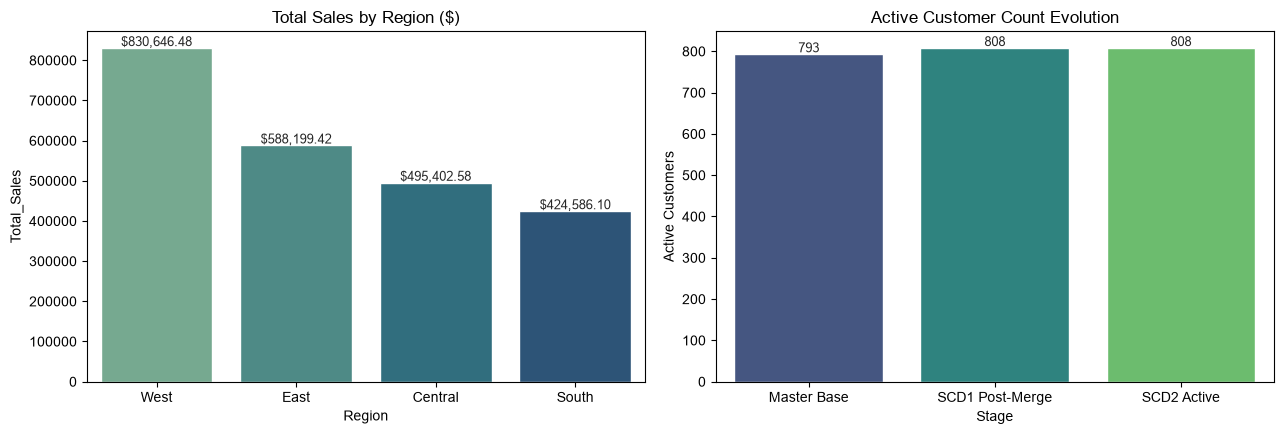

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
sns.set_theme(style="whitegrid")

sns.barplot(data=summary_df, x="Region", y="Total_Sales", hue="Region", palette="crest", ax=ax1, legend=False)
ax1.set_title("Total Sales by Region ($)")
for p in ax1.patches:
    ax1.annotate(f"${p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 4), textcoords='offset points', fontsize=9)

pipeline_df = pd.DataFrame({
    "Stage": ["Master Base", "SCD1 Post-Merge", "SCD2 Active"],
    "Active Customers": [len(clean_master_df), len(clean_master_df) + 15, active_count]
})
sns.barplot(data=pipeline_df, x="Stage", y="Active Customers", hue="Stage", palette="viridis", ax=ax2, legend=False)
ax2.set_title("Active Customer Count Evolution")
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 4), textcoords='offset points', fontsize=9)

plt.tight_layout()
os.makedirs("../screenshots/final_output", exist_ok=True)
plt.savefig("../screenshots/final_output/final_output.png", dpi=300)
plt.show()
